In [17]:
import warnings

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.exceptions import ConvergenceWarning
from scipy.stats import ks_2samp

# Условие
1. Обучить линейную регрессионную модель при различных параметрах конструктора признаков PolynomialFeatures
2. Обучить линейную модель LASSO в тех же признаковых пространствах с подбором параметра регуляризации alpha на основе валидации «вручную»

In [18]:
data = pd.read_csv("fish.csv")
data.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


Пропусков в данных нет

# Задание 1

In [20]:
X = data.drop(columns=['Species', 'Weight'], axis=1)
y = data['Weight']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=675)

In [22]:
def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

## Обучение моделей

In [23]:
results = []
for degree in [1, 2, 3, 4]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_poly)
    X_test_scaled = scaler.transform(X_test_poly)

    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    mae_train, rmse_train = metrics(y_train, y_train_pred)
    mae_test, rmse_test = metrics(y_test, y_test_pred)

    r_train = y_train - y_train_pred
    r_test = y_test - y_test_pred
    ks_stat, ks_pvalue = ks_2samp(r_train, r_test)
    results.append({
        'degree': degree,
        'MAE_train': mae_train,
        'MAE_test': mae_test,
        'RMSE_train': rmse_train,
        'RMSE_test': rmse_test,
        'MAE test-train': mae_test - mae_train,
        'KS_stat': ks_stat,
        'KS_pvalue': ks_pvalue
    })

## Анализ результатов

In [24]:
res_df = pd.DataFrame(results).sort_values('degree')
res_df['Переобучена'] = res_df['KS_pvalue'] < 0.05
print(res_df.to_string(index=False))

 degree  MAE_train    MAE_test  RMSE_train   RMSE_test  MAE test-train  KS_stat    KS_pvalue  Переобучена
      1  87.707958  111.746554  116.699496  138.048794       24.038596 0.145833 4.253449e-01        False
      2  25.475582   48.365588   36.959187   71.668437       22.890006 0.174550 2.262559e-01        False
      3  14.677443   63.100330   21.624272  100.925376       48.422887 0.246622 2.741102e-02         True
      4   0.450451 1563.869415    3.355780 2652.550882     1563.418964 0.490991 6.955206e-08         True


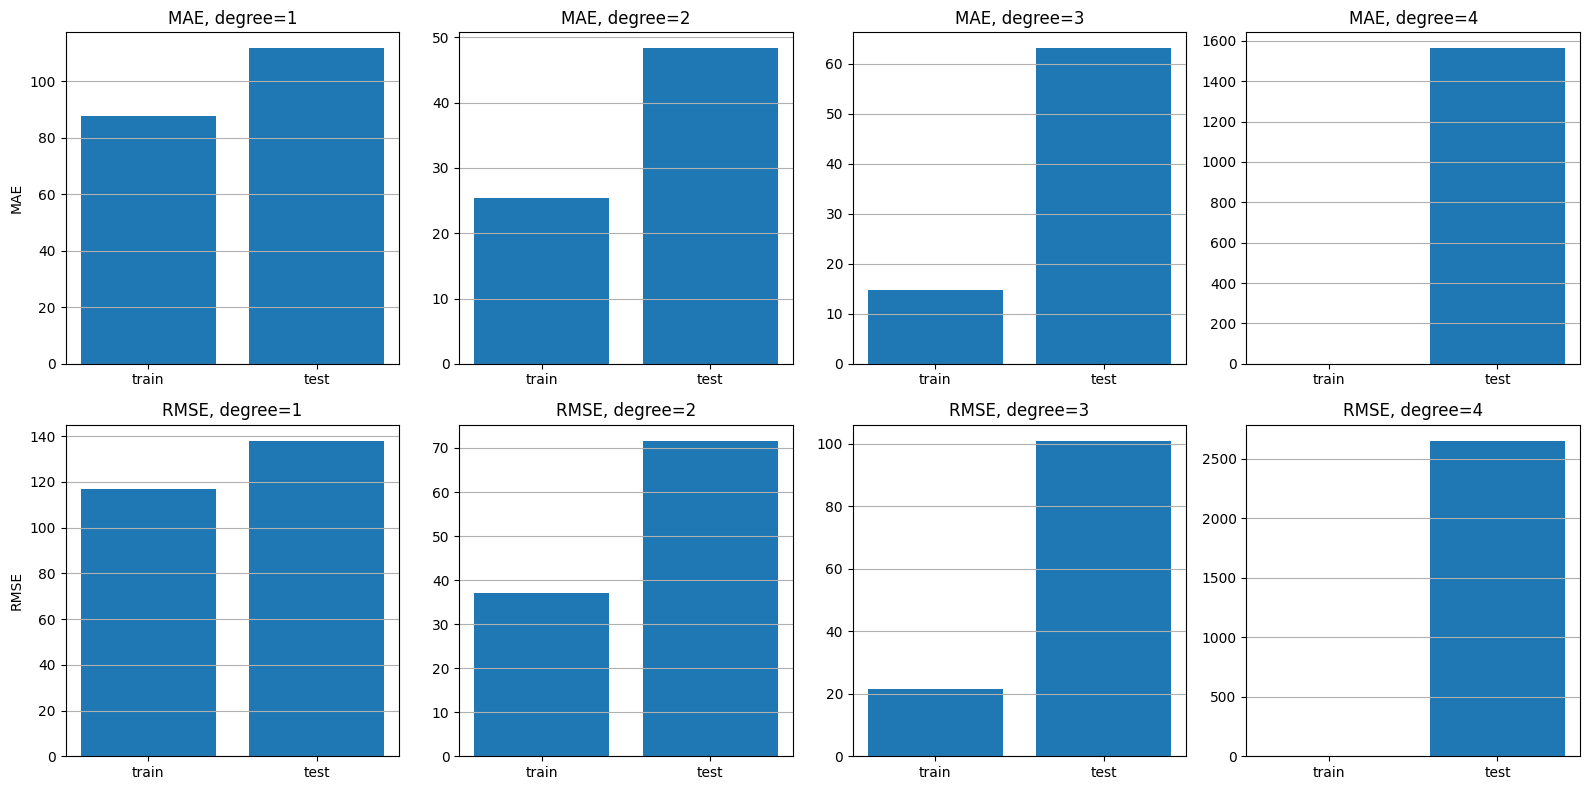

In [25]:
df = res_df.set_index('degree')
degrees = list(df.index)
n = len(degrees)

fig, axes = plt.subplots(2, n, figsize=(4*n, 8))

for j, d in enumerate(degrees):
    ax1 = axes[0, j] if n > 1 else axes[0]
    ax1.bar(['train', 'test'], [df.loc[d, 'MAE_train'], df.loc[d, 'MAE_test']])
    ax1.set_title(f'MAE, degree={d}')
    ax1.grid(True, axis='y')
    if j == 0:
        ax1.set_ylabel('MAE')

    ax2 = axes[1, j] if n > 1 else axes[1]
    ax2.bar(['train', 'test'], [df.loc[d, 'RMSE_train'], df.loc[d, 'RMSE_test']])
    ax2.set_title(f'RMSE, degree={d}')
    ax2.grid(True, axis='y')
    if j == 0:
        ax2.set_ylabel('RMSE')

plt.tight_layout()
plt.show()

Видно, что модель переобучилась при степени 3 и 4. При этом степень 2 является оптимальной: она учитывает квадратичные зависимости, что позволяет снизить ошибку по сравнению с 1 степенью, минимизирует ошибку на тестовой выборке среди всех степеней, при этом разность между метриками train и test остается не слишком большой.

На 4 степени ошибки на train вообще равны 0, что говорит об очень сильном переобучении.

Тест Колмогорова-Смирнова подтвердил наблюдения на графиках - модель переобучилась при 3 и 4 степени

# Задание 2

In [26]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=675)

## Обучение моделей

Для того, чтобы найти лучший параметр, я буду перебирать 40 alpha от 1e-6 до 1e2.

In [27]:
lasso_results = []
alphas = np.logspace(-6, 2, 40)

warnings.filterwarnings('ignore', category=ConvergenceWarning)

for degree in [1, 2, 3, 4]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)

    X_tr_poly = poly.fit_transform(X_tr)
    X_val_poly = poly.transform(X_val)

    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr_poly)
    X_val_scaled = scaler.transform(X_val_poly)

    for a in alphas:
        model = Lasso(alpha=a, max_iter=20000, random_state=675)
        model.fit(X_tr_scaled, y_tr)

        y_tr_pred = model.predict(X_tr_scaled)
        y_val_pred = model.predict(X_val_scaled)

        mae_train = mean_absolute_error(y_tr, y_tr_pred)
        mae_val = mean_absolute_error(y_val, y_val_pred)

        rmse_train = np.sqrt(mean_squared_error(y_tr, y_tr_pred))
        rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))

        r_tr = y_tr - y_tr_pred
        r_val = y_val - y_val_pred

        ks_stat, ks_pvalue = ks_2samp(r_tr, r_val)

        lasso_results.append({
            'degree': degree,
            'alpha': a,
            'MAE_train': mae_train,
            'MAE_val': mae_val,
            'RMSE_train': rmse_train,
            'RMSE_val': rmse_val,
            'KS_stat': ks_stat,
            'KS_pvalue': ks_pvalue
        })

lasso_grid_df = pd.DataFrame(lasso_results)

## Анализ результатов

In [28]:
degrees = list(pd.Index(lasso_grid_df['degree']).unique())

best_rows = []
for d in degrees:
    df_d = lasso_grid_df[lasso_grid_df['degree'] == d]
    best_rows.append(df_d.loc[df_d['MAE_val'].idxmin()])

best_alpha_df = pd.DataFrame(best_rows).reset_index(drop=True)
best_df = best_alpha_df.copy()
best_df['MAE_test'] = best_df['MAE_val']
best_df['RMSE_test'] = best_df['RMSE_val']
best_df['Переобучена'] = best_df['KS_pvalue'] < 0.05

print(best_df.to_string(index=False))

 degree     alpha  MAE_train   MAE_val  RMSE_train   RMSE_val  KS_stat  KS_pvalue  MAE_test  RMSE_test  Переобучена
    1.0  0.888624  85.505660 99.025129  115.165284 128.615941 0.114130   0.945341 99.025129 128.615941        False
    2.0  0.554102  26.941494 41.951288   41.528442  63.534146 0.226779   0.256561 41.951288  63.534146        False
    3.0 38.881552  40.089114 41.883184   61.353248  55.593952 0.151186   0.732260 41.883184  55.593952        False
    4.0  0.083768  18.869629 41.578964   30.512846  65.894236 0.194664   0.429488 41.578964  65.894236        False


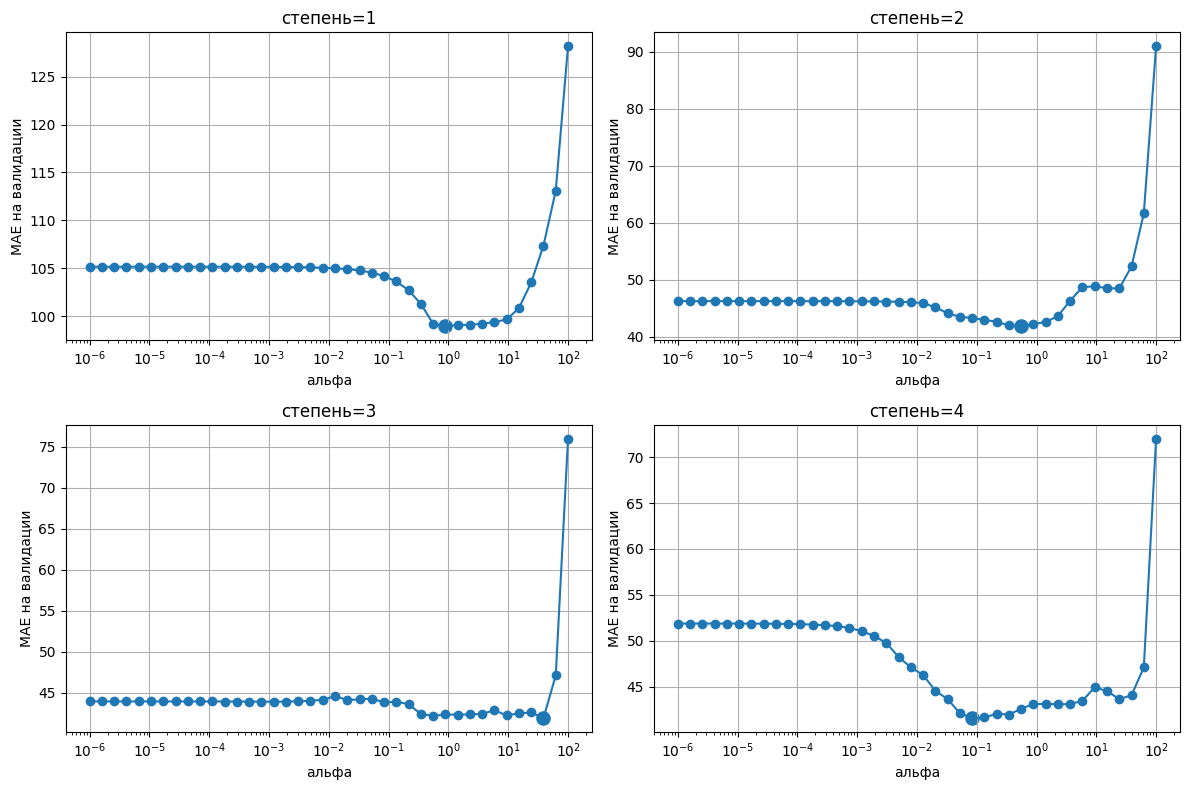

In [29]:
degrees = list(pd.Index(lasso_grid_df['degree']).unique())
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, d in enumerate(degrees):
    ax = axes[i]
    df_d = lasso_grid_df[lasso_grid_df['degree'] == d].sort_values('alpha')

    ax.plot(df_d['alpha'], df_d['MAE_val'], marker='o')
    best_idx = df_d['MAE_val'].idxmin()
    ax.scatter([df_d.loc[best_idx, 'alpha']], [df_d.loc[best_idx, 'MAE_val']], s=90)

    ax.set_xscale('log')
    ax.set_title(f'степень={d}')
    ax.set_xlabel('alpha')
    ax.set_ylabel('МАЕ на валидации')
    ax.grid(True)

plt.tight_layout()
plt.show()

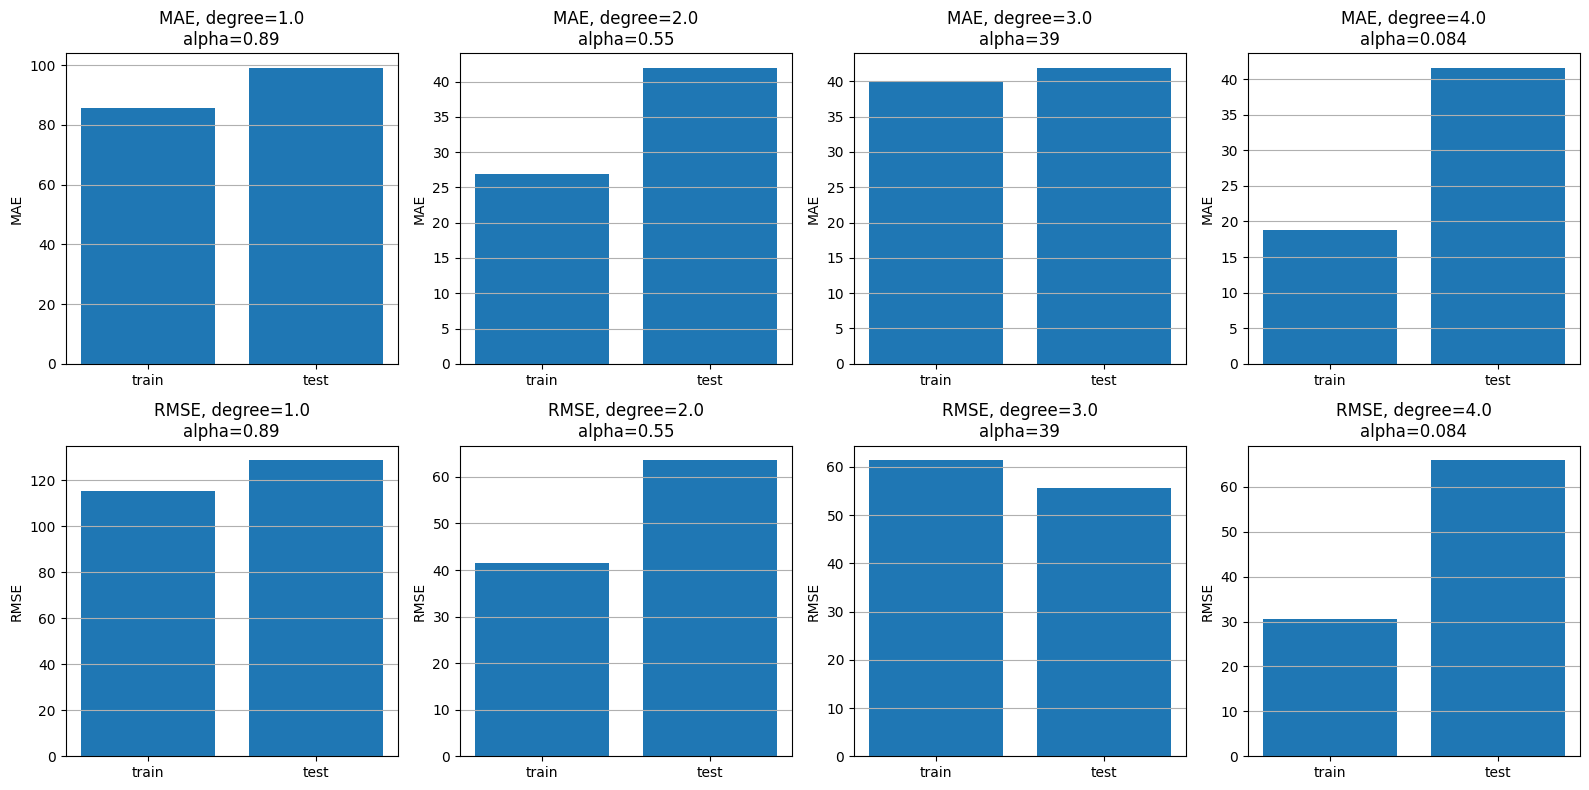

In [30]:
df = best_df.set_index('degree')
degrees = list(df.index)
n = len(degrees)

fig, axes = plt.subplots(2, n, figsize=(4*n, 8))

for j, d in enumerate(degrees):
    ax1 = axes[0, j] if n > 1 else axes[0]
    ax1.bar(['train', 'test'], [df.loc[d, 'MAE_train'], df.loc[d, 'MAE_test']])
    ax1.set_title(f'MAE, degree={d}\nalpha={df.loc[d,"alpha"]:.2g}')
    ax1.grid(True, axis='y')
    ax1.set_ylabel('MAE')

    ax2 = axes[1, j] if n > 1 else axes[1]
    ax2.bar(['train', 'test'], [df.loc[d, 'RMSE_train'], df.loc[d, 'RMSE_test']])
    ax2.set_title(f'RMSE, degree={d}\nalpha={df.loc[d,"alpha"]:.2g}')
    ax2.grid(True, axis='y')
    ax2.set_ylabel('RMSE')

plt.tight_layout()
plt.show()

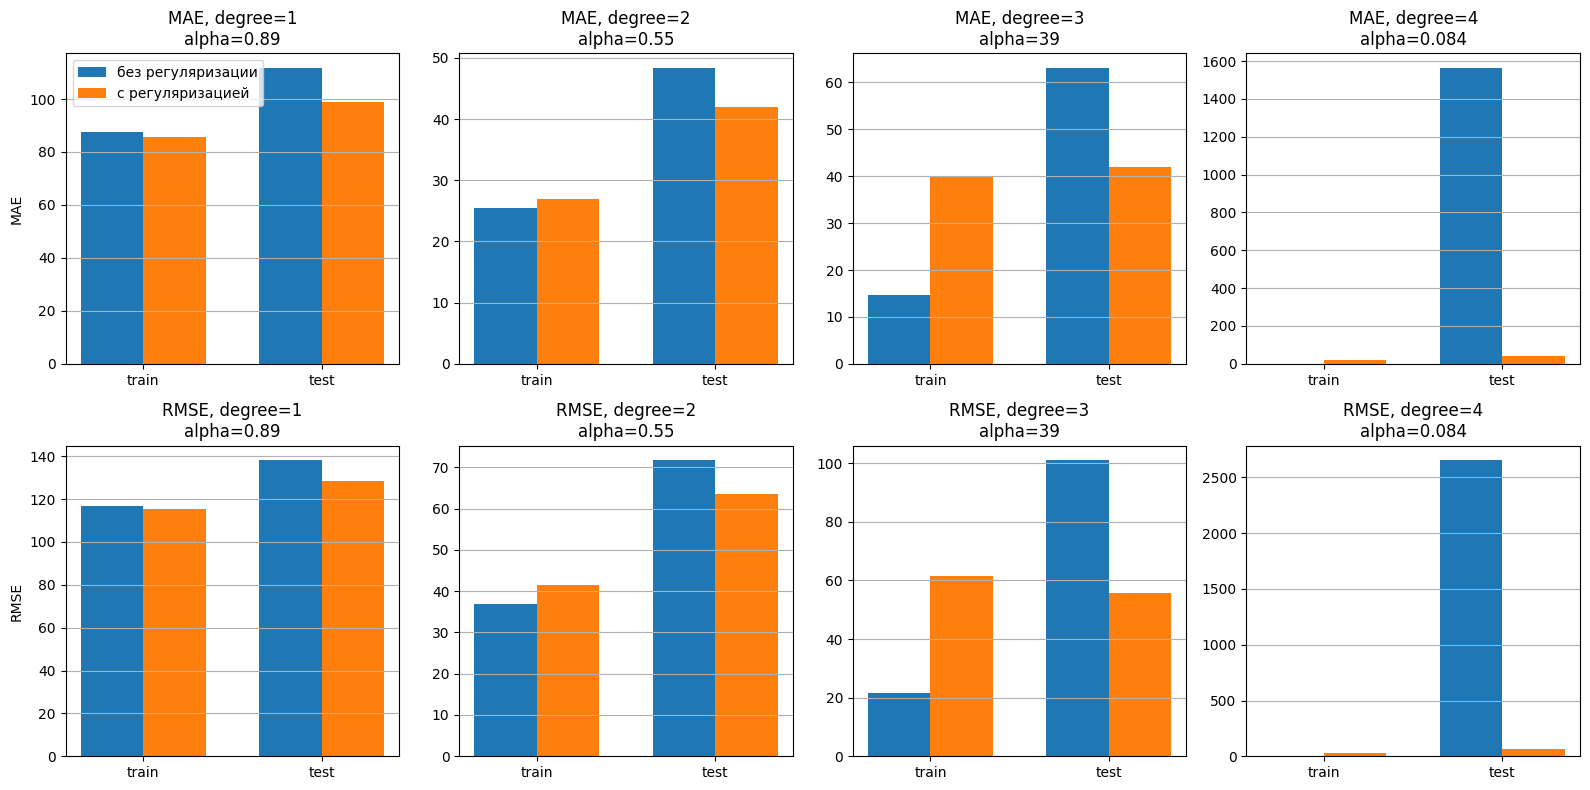

In [31]:
df_lr = res_df.set_index('degree')
df_lasso = best_df.set_index('degree')

degrees = list(df_lr.index)
n = len(degrees)

fig, axes = plt.subplots(2, n, figsize=(4*n, 8))

bar_w = 0.35
x = np.arange(2)

for j, d in enumerate(degrees):
    mae_lr = [df_lr.loc[d, 'MAE_train'], df_lr.loc[d, 'MAE_test']]
    rmse_lr = [df_lr.loc[d, 'RMSE_train'], df_lr.loc[d, 'RMSE_test']]

    if d in df_lasso.index:
        mae_lasso = [df_lasso.loc[d, 'MAE_train'], df_lasso.loc[d, 'MAE_test']]
        rmse_lasso = [df_lasso.loc[d, 'RMSE_train'], df_lasso.loc[d, 'RMSE_test']]
        alpha_val = df_lasso.loc[d, 'alpha']
        alpha_suffix = f'\nalpha={alpha_val:.2g}'
    else:
        mae_lasso = [np.nan, np.nan]
        rmse_lasso = [np.nan, np.nan]
        alpha_suffix = ''

    ax1 = axes[0, j] if n > 1 else axes[0]
    ax1.bar(x - bar_w/2, mae_lr, bar_w, label='без регуляризации')
    ax1.bar(x + bar_w/2, mae_lasso, bar_w, label='с регуляризацией')
    ax1.set_xticks(x)
    ax1.set_xticklabels(['train', 'test'])
    ax1.set_title(f'MAE, degree={d}{alpha_suffix}')
    ax1.grid(True, axis='y')
    if j == 0:
        ax1.set_ylabel('MAE')
        ax1.legend()

    ax2 = axes[1, j] if n > 1 else axes[1]
    ax2.bar(x - bar_w/2, rmse_lr, bar_w, label='без регуляризации')
    ax2.bar(x + bar_w/2, rmse_lasso, bar_w, label='с регуляризацией')
    ax2.set_xticks(x)
    ax2.set_xticklabels(['train', 'test'])
    ax2.set_title(f'RMSE, degree={d}{alpha_suffix}')
    ax2.grid(True, axis='y')
    if j == 0:
        ax2.set_ylabel('RMSE')

plt.tight_layout()
plt.show()

С регуляризацией модель перестала переобучаться: этот вывод можно сделать как из графиков, так и на основании p-value.